# Listen & check — target-speaker VAD

A control panel for your ears. For one synthesized val scene you can play:
1. the **enrollment** (what the model was told the target sounds like),
2. the **full dialog**,
3. what the model would **record** (predicted target-only, merged),
4. the **correct** part of that recording (TP), the **false triggers** (FP), and the **missed** target audio (FN).

Everything is regenerated deterministically from the scene seed, so it matches the cached features the model was scored on.

**How to use:** Run all cells. Change `PICK` in the scene-selection cell to inspect a different scene, then re-run from there down.


## Setup


In [1]:

import os, sys
from pathlib import Path
root = Path.cwd()
while not (root / 'ROADMAP.md').exists() and root != root.parent:
    root = root.parent
os.chdir(root); sys.path.insert(0, str(root))
print('repo root:', root)

import numpy as np
import soundfile as sf
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import Audio, display

from src.eval.metrics_example import runs_of_true, frame_metrics, format_metrics
from src.eval.eval_model_example import load_model
from src.synth.speaker_splits_example import load_splits
from src.features.build_feature_cache_example import noise_splits
from src.synth.synthesize_scene_example import synthesize_scene, TARGET_ONLY, CLASS_NAMES

SR, HOP = 16000, 160   # 16 kHz audio, 10 ms label/feature grid

def merge_segments(wav, frame_mask, gap_s=0.3):
    """Concatenate the audio under True frames, a short silence between runs."""
    gap = np.zeros(int(gap_s * SR), dtype=np.float32)
    pieces = []
    for a, b in runs_of_true(frame_mask):
        pieces.append(wav[a*HOP : min(len(wav), b*HOP)])
        pieces.append(gap)
    return np.concatenate(pieces) if pieces else np.zeros(1, dtype=np.float32)

def secs(mask):
    return float(mask.sum()) * HOP / SR


repo root: /Users/ihsanbolum/Target Person Voice


## Pick a scene & run the model

`PICK` indexes the cached val scenes. Try a few — scenes with a **low TIR** (interferer roughly as loud as the target) are easier; **high TIR** (interferer much quieter) is the hard overlap case (§3-C).


In [10]:
VAL_FEAT = root / 'data' / 'features_noisy' / 'val'
npz_files = sorted(VAL_FEAT.glob('scene_seed*.npz'))
print(f'{len(npz_files)} val scenes available (index 0..{len(npz_files)-1})')

PICK = 0   # <-- change me to inspect a different scene

npz_path = npz_files[PICK]
seed = int(npz_path.stem.replace('scene_seed', ''))
splits = load_splits()
noise_files =  noise_splits()['val']
wav, _labels_syn, meta = synthesize_scene(seed, splits['val'], noise_files=noise_files)   # deterministic from seed
feat = np.load(npz_path)
labels = feat['labels']

model = load_model()
with torch.no_grad():
    logits = model(torch.from_numpy(feat['logmel']).float()[None],
                   torch.from_numpy(feat['emb']).float()[None],
                   torch.from_numpy(feat['cos']).float()[None],
                   torch.from_numpy(feat['vad']).float()[None])
pred = logits[0].argmax(-1).numpy()

# Boolean per-frame masks (positive class = target-only).
true_t = labels == TARGET_ONLY
pred_t = pred  == TARGET_ONLY
tp = true_t & pred_t       # correctly recorded
fp = pred_t & ~true_t      # false trigger: recorded but not target
fn = true_t & ~pred_t      # miss: dropped target audio

m = frame_metrics(true_t, pred_t)
print(f'seed={seed}  target={meta["target"]}  interferers={meta["interferers"]}  '
      f'TIR={meta["tir_db"]:+.1f} dB  dialog={len(wav)/SR:.1f}s')
print('this scene, target-only:', format_metrics(m))


20 val scenes available (index 0..19)
seed=100000  target=p297  interferers=['p261']  TIR=+11.9 dB  dialog=22.6s
this scene, target-only: P=0.842 R=0.810 F1=0.826 | false_trigger=0.163 miss=0.190 (TP=949 FP=178 FN=222 TN=912)


## 1. Enrollment — what the model thinks the target sounds like

The clean reference clips that were averaged into `e_target`. (First 6 of 20, for brevity.)


In [11]:
enroll = []
for f in meta['enrollment_files'][:6]:
    sig, sr = sf.read(f, dtype='float32')
    enroll.append(sig); enroll.append(np.zeros(int(0.2*SR), dtype=np.float32))
enroll = np.concatenate(enroll)
print(f'target speaker = {meta["target"]}')
display(Audio(enroll, rate=SR))


target speaker = p297


## 2. The full dialog (single mic)

The mixed scene the model has to analyze. Target + interferer(s), with gaps and overlaps.


In [12]:
display(Audio(wav, rate=SR))


## 3. What the model would RECORD

Only the frames the model labels **target-only**, merged back to back. This is the actual deliverable — what the pipeline would extract. Listen for: is it the target's voice throughout? Any other speaker leaking in (false trigger)?


In [13]:
print(f'predicted target-only: {secs(pred_t):.1f}s of {len(wav)/SR:.1f}s dialog')
display(Audio(merge_segments(wav, pred_t), rate=SR))


predicted target-only: 11.3s of 22.6s dialog


## 4. Breaking the recording into right vs wrong

- **TP** — correctly recorded target audio.
- **FP (false triggers)** — recorded, but it's *not* the target alone (other speaker or overlap). This is what pollutes the output.
- **FN (misses)** — true target audio the model dropped.


In [14]:
print(f'TP  correctly recorded : {secs(tp):.1f}s')
display(Audio(merge_segments(wav, tp), rate=SR))


TP  correctly recorded : 9.5s


In [15]:
print(f'FP  false triggers     : {secs(fp):.1f}s  (should NOT be the target alone)')
display(Audio(merge_segments(wav, fp), rate=SR))


FP  false triggers     : 1.8s  (should NOT be the target alone)


In [16]:
print(f'FN  missed target audio: {secs(fn):.1f}s  (target we dropped)')
display(Audio(merge_segments(wav, fn), rate=SR))


FN  missed target audio: 2.2s  (target we dropped)


## 5. Visual: true vs predicted timeline

Same time axis as the audio. Green = target-only (record), blue = other-only, red = overlap, grey = silence. Compare the two strips to see where predictions drift.


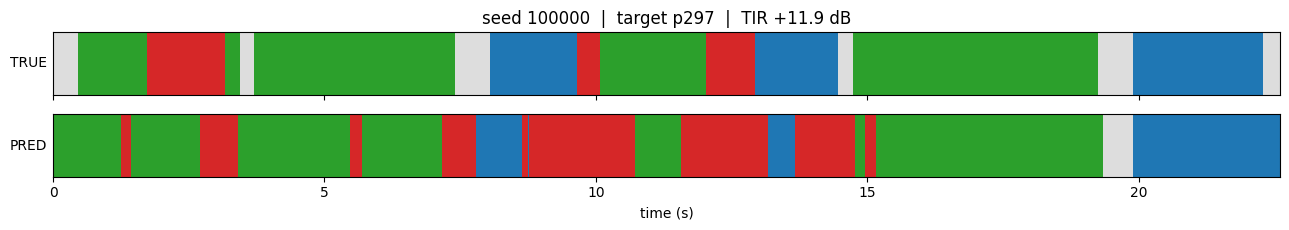

In [17]:
cmap = ListedColormap(['#dddddd', '#2ca02c', '#1f77b4', '#d62728'])
dur = len(wav) / SR
fig, axes = plt.subplots(2, 1, figsize=(13, 2.4), sharex=True)
for ax, arr, name in [(axes[0], labels, 'TRUE'), (axes[1], pred, 'PRED')]:
    ax.imshow(arr[None, :], aspect='auto', cmap=cmap, vmin=0, vmax=3,
              extent=[0, dur, 0, 1], interpolation='nearest')
    ax.set_yticks([]); ax.set_ylabel(name, rotation=0, ha='right', va='center')
axes[1].set_xlabel('time (s)')
axes[0].set_title(f'seed {seed}  |  target {meta["target"]}  |  TIR {meta["tir_db"]:+.1f} dB')
plt.tight_layout(); plt.show()
